# IMPLEMENT MACHINE TRANSLATION USING TRANSFORMER

## Objective:
Train a Transformer model on French-English translation task using the fra-eng dataset.

## STEP 1 - Import libraries

### 1.1 Clone repository

In [1]:
import shutil
import os

# Remove existing folder if it exists
if os.path.exists('DL_self_practice'):
    shutil.rmtree('DL_self_practice')

# Clone repository
!git clone https://github.com/ArrayPowerPlay/DL_self_practice.git

# Navigate to the project root 
os.chdir('DL_self_practice')

Cloning into 'DL_self_practice'...
remote: Enumerating objects: 134, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 134 (delta 4), reused 13 (delta 3), pack-reused 115 (from 1)
Receiving objects: 100% (134/134), 118.03 MiB | 22.36 MiB/s, done.
Resolving deltas: 100% (60/60), done.


### 1.2. Import libraries

In [2]:
import os 
import torch
from utils import spy

### 1.3. Check if GPU is available

In [3]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(os.getcwd())

True
Tesla P100-PCIE-16GB
/kaggle/working/DL_self_practice


## STEP 2 - Load and preprocess data

In [4]:
# Load fra-eng dataset using MachineTranslation class
PATH = '/kaggle/input/frag-txt/fra.txt'

data = spy.MachineTranslation(
    path=PATH,
    batch_size=128,              
    num_steps=25,                
    num_train=60000,           
    num_val=5000                 
)

print(f"Source vocabulary size: {len(data.src_vocab)}")
print(f"Target vocabulary size: {len(data.tgt_vocab)}")
print(f"Training examples: {data.num_train}")
print(f"Validation examples: {data.num_val}")

Source vocabulary size: 5017
Target vocabulary size: 8693
Training examples: 60000
Validation examples: 5000


## STEP 3 - Define Transformer model

### 3.1. Define some hyperparameters

In [5]:
num_hiddens, num_blks, dropout = 512, 6, 0.15
ffn_num_hiddens, num_heads = 2048, 8

### 3.2. Define Transformer encoder

In [6]:
encoder = spy.TransformerEncoder(
    len(data.src_vocab), num_hiddens, ffn_num_hiddens, 
    num_heads, num_blks, dropout
)

### 3.3. Define Transformer decoder

In [7]:
decoder = spy.TransformerDecoder(
    len(data.tgt_vocab), num_hiddens, ffn_num_hiddens, 
    num_heads, num_blks, dropout
)

### 3.4. Define Transformer model

In [8]:
model = spy.Seq2Seq(
    encoder, 
    decoder, 
    tgt_pad=data.tgt_vocab['<pad>'],
    lr=5e-4
) 

## STEP 4 - Training model

### 4.1. Create convenient functions

In [9]:
import math

# Learning rate scheduler for training optimization
def get_lr_scheduler(optimizer, total_epochs):
    """Warm-up + cosine annealing learning rate scheduler"""
    def lr_lambda(epoch):
        warmup_epochs = 5
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        else:
            progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
            return 0.5 * (1 + math.cos(math.pi * progress))
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

### 4.2. Create a custom Transformer trainer class with learning rate scheduler

In [10]:
class TransformerTrainer(spy.Trainer):
    def prepare_model(self, model):
        super().prepare_model(model)
        self.scheduler = get_lr_scheduler(self.optimizer, self.max_epochs)

### 4.3. Training Transformer model

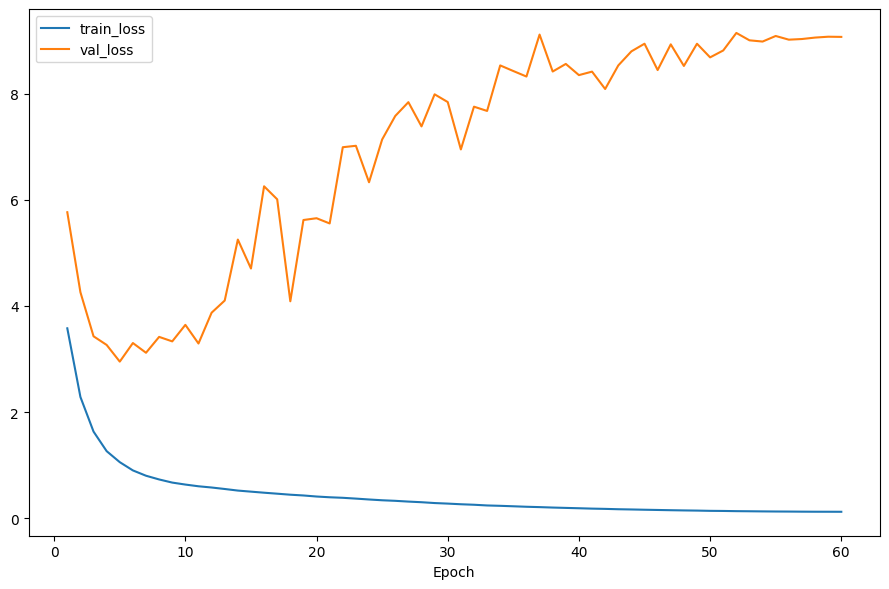

In [11]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
max_epochs = 60

trainer = TransformerTrainer(max_epochs=max_epochs, gradient_clip_val=1, device=device)
trainer.fit(model, data)

In [15]:
print(model.board['train_loss'][-1])
print(model.board['val_loss'][-1])

0.12038444772140304
9.071246397495269


### 4.4. Save checkpoints

In [12]:
torch.save({
    "model": model.state_dict(),
    "board": model.board,
    "optimizer": trainer.optimizer.state_dict(),
    "scheduler": trainer.scheduler.state_dict()
}, "machine_translation_checkpoint.pt")

print("Checkpoint saved!")

Checkpoint saved!


## STEP 5 - Test translation

### 5.1. Test on validation data and view BLEU score

In [13]:
# Evaluate on validation data
model.eval()

for batch in list(data.val_dataloader())[:8]:
    batch = [b.to(trainer.device) for b in batch]
    src, tgt_input, src_valid_len, tgt_output = batch
    preds, _ = model.predict_step(batch, trainer.device, data.num_steps)
    
    for s, t, p in zip(src, tgt_output, preds):
        src_str = ' '.join(data.src_vocab.
                    to_tokens(s.cpu().tolist())).replace('<pad>', '').replace('<eos>', '').strip()
        
        ref_tokens = []
        for i in t:
            token = data.tgt_vocab.to_tokens(i.item())
            if token == '<eos>':
                break
            if token != '<pad>':
                ref_tokens.append(token)
        ref_str = ' '.join(ref_tokens).strip()
        
        pred_tokens = []
        for i in p:
            token = data.tgt_vocab.to_tokens(i.item())
            if token == '<eos>':
                break
            if token != '<pad>':
                pred_tokens.append(token)
        pred_str = ' '.join(pred_tokens).strip()
        
        bleu = spy.bleu(pred_str, ref_str, k=4)
        print(f'{src_str} => {pred_str} - bleu: {bleu:.3f}')

i've just read this book . => je viens de lire ce livre . - bleu: 0.744
i've lost about 80 <unk> . => j'ai perdu de <unk> . - bleu: 0.000
i've lost my best friend . => j'ai perdu mon meilleur ami . - bleu: 1.000
i've lost my best friend . => j'ai perdu mon meilleur ami . - bleu: 0.000
i've never been so proud . => je n'ai jamais été si fière . - bleu: 0.752
i've never been so proud . => je n'ai jamais été si fière . - bleu: 1.000
i've never considered it . => je n'y ai jamais songé . - bleu: 0.000
i've never heard of that . => je n'ai jamais entendu ça . - bleu: 0.000
i've never worn a <unk> . => je n'ai jamais épuisé un courrier <unk> . - bleu: 0.000
i've only just come back . => je viens juste de rentrer . - bleu: 1.000
i've only just come back . => je viens juste de rentrer . - bleu: 0.000
i've painted the ceiling . => j'ai peint le plafond . - bleu: 1.000
i've read the first page . => j'ai lu la page . - bleu: 0.000
i've rented an apartment . => j'ai loué un appartement . - bleu: 1

### 5.2. Translate a random English sentence

In [20]:
# Translate a single English sentence
eng = "I love playing tennis"

# Build batch from English sentence (dummy French for reference)
batch = data.build([eng], [""])  # Empty string for target (not used for prediction)
batch = [b.to(trainer.device) for b in batch]

# Get predictions
preds, _ = model.predict_step(batch, trainer.device, data.num_steps)

# Convert predictions to tokens
pred_tokens = []
for token_idx in preds[0]:
    token = data.tgt_vocab.to_tokens(token_idx.item())
    if token == '<eos>':
        break
    if token != '<pad>':
        pred_tokens.append(token)

# Join tokens into sentence
fra = ' '.join(pred_tokens)

print(f"English: {eng}")
print(f"French:  {fra}")

English: I love playing tennis
French:  j'adore jouer au tennis .
